<a href="https://colab.research.google.com/github/juanarrow/BigData-notebooks/blob/main/Dijkstra_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
def generate_graph(num_nodes, edge_probability = 0.5, max_weight = 100):
  graph = {node: [] for node in range(num_nodes)}

  for i in range(num_nodes):
    for j in range(num_nodes):
      if i != j and random.random() < edge_probability:
        graph[i].append((j, random.randint(1, max_weight)))
  return graph


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph):
  G = nx.DiGraph()

  for node in graph:
    G.add_node(node)
    for neighbor, weight in graph[node]:
      G.add_edge(node, neighbor, weight=weight)

  plt.figure(figsize=(12, 8))
  pos = nx.spring_layout(G, seed=42)

  # Dibujamos los nodos
  nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
  nx.draw_networkx_labels(G, pos, font_size=12, font_family='sans-serif')

  # Usamos una conexión curvada para separar las aristas de ida y vuelta
  connection_style = "arc3,rad=0.15"
  nx.draw_networkx_edges(
      G, pos,
      edge_color='green',
      connectionstyle=connection_style,
      arrowsize=20
  )

  # Dibujamos las etiquetas de las aristas curvadas
  edge_labels = {(u, v): w for u, v, w in G.edges(data='weight')}
  nx.draw_networkx_edge_labels(
      G, pos,
      edge_labels=edge_labels,
      label_pos=0.3,
      font_size=10,
      connectionstyle=connection_style
  )

  plt.axis('off')
  plt.show()

[ True False False]
[ True False False]
[False  True False]
[ True False  True]
{0: [(1, 46)], 1: [(0, 6)], 2: [(1, 88)], 3: [(0, 97), (2, 45)]}


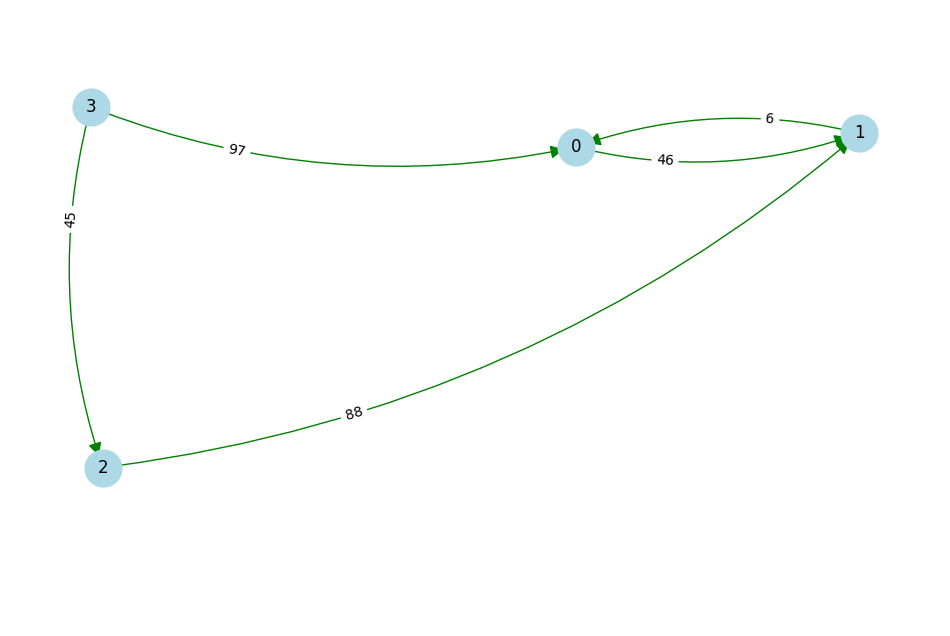

In [3]:
import heapq

graph = generate_graph(4)
print(graph)
draw_graph(graph)
def dijkstra(graph, start_node):

  distances = {node: float('inf') for node in graph}

  distances[start_node] = 0

  priority_nodes = [(0, start_node)]

  while priority_nodes:
    current_distance, current_node = heapq.heappop(priority_nodes)
    if current_distance > distances[current_node]:
      continue

    for neighbor, weight in graph[current_node]:
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        heapq.heappush(priority_nodes, (distance, neighbor))

  return distances

distances = dijkstra(graph, 0)



In [ ]:
import time
sizes = [200, 400, 800, 1600, 3200, 6400, 12800, 25200]
times = []

for size in sizes:
  start_time = time.perf_counter()
  graph = generate_graph(size, 0.25)
  end_time = time.perf_counter()
  print(f"graph of {size} generated in {end_time - start_time} segundos")
  start_time = time.perf_counter()
  _ = dijkstra(graph, 0)
  end_time = time.perf_counter()
  print(f"dijkstra of {size} executed in {end_time - start_time} segundos")
  times.append(end_time - start_time)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(sizes, times, marker='o')
plt.xlabel('Tamaño del grafo')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Tiempo de ejecución de Dijkstra en función del tamaño del grafo')

graph of 200 generated in 0.5591822409999168 segundos
dijkstra of 200 executed in 0.002626834000011513 segundos
graph of 400 generated in 0.03146957000012662 segundos
dijkstra of 400 executed in 0.006965026999978363 segundos
graph of 800 generated in 0.07506971799989515 segundos
dijkstra of 800 executed in 0.020120568999800525 segundos
graph of 1600 generated in 0.2519148999999743 segundos
dijkstra of 1600 executed in 0.07040432999997392 segundos
graph of 3200 generated in 0.9607751659998485 segundos
dijkstra of 3200 executed in 0.29302855100013403 segundos
graph of 6400 generated in 4.281476972000064 segundos
dijkstra of 6400 executed in 1.8059957410000607 segundos
graph of 12800 generated in 18.83391973000016 segundos
dijkstra of 12800 executed in 4.011407033000069 segundos
